# Etape 1 : Importation des bibliothèques

In [1]:
# Bibliothèques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import calendar
import tarfile
import os
import re
import missingno as msno
import plotly.express as px
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import plot_tree
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix

# Paramètres d'affichage
plt.rcParams['figure.figsize'] = (12, 9)
sns.set_theme()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings("ignore", category=FutureWarning)

# Etape 2 : Chargement et exploration des données

In [2]:
# Extraction des données
directory_path = os.getcwd()
file_path = os.path.join(directory_path, 'in_out_time.zip')
extract_path = os.path.join(directory_path, 'in_out_time')

# Créer le dossier s'il n'existe pas
if not os.path.exists(extract_path):
    os.makedirs(extract_path)

# Extraire le zip
with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(path=extract_path)

# Chemins des fichiers
out_time_path = os.path.join(extract_path, 'out_time.csv')
in_time_path = os.path.join(extract_path, 'in_time.csv')
employee_path = os.path.join(directory_path, 'employee_survey_data.csv')
manager_path = os.path.join(directory_path, 'manager_survey_data.csv')
general_path = os.path.join(directory_path, 'general_data.csv')

# Lecture des fichiers CSV
in_time_data = pd.read_csv(in_time_path)
out_time_data = pd.read_csv(out_time_path)
employee_data = pd.read_csv(employee_path)
manager_data = pd.read_csv(manager_path)
general_data = pd.read_csv(general_path)

# Vérification rapide
#print(in_time_data.head())
#print(out_time_data.head())

In [3]:
# Renommer la première colonne de in_out_time en employeeID
in_time_data.rename(columns={in_time_data.columns[0]: 'EmployeeID'}, inplace=True)
out_time_data.rename(columns={out_time_data.columns[0]: 'EmployeeID'}, inplace=True)

In [4]:
# Affichage des premières colonnes
print(in_time_data.head(5))
print(out_time_data.head(5))
print(employee_data.head(5))
print(manager_data.head(5))
print(general_data.head(5))

   EmployeeID  2015-01-01           2015-01-02           2015-01-05  \
0           1         NaN  2015-01-02 09:43:45  2015-01-05 10:08:48   
1           2         NaN  2015-01-02 10:15:44  2015-01-05 10:21:05   
2           3         NaN  2015-01-02 10:17:41  2015-01-05 09:50:50   
3           4         NaN  2015-01-02 10:05:06  2015-01-05 09:56:32   
4           5         NaN  2015-01-02 10:28:17  2015-01-05 09:49:58   

            2015-01-06           2015-01-07           2015-01-08  \
0  2015-01-06 09:54:26  2015-01-07 09:34:31  2015-01-08 09:51:09   
1                  NaN  2015-01-07 09:45:17  2015-01-08 10:09:04   
2  2015-01-06 10:14:13  2015-01-07 09:47:27  2015-01-08 10:03:40   
3  2015-01-06 10:11:07  2015-01-07 09:37:30  2015-01-08 10:02:08   
4  2015-01-06 09:45:28  2015-01-07 09:49:37  2015-01-08 10:19:44   

            2015-01-09           2015-01-12           2015-01-13  2015-01-14  \
0  2015-01-09 10:09:25  2015-01-12 09:42:53  2015-01-13 10:13:06         NaN   
1  2

In [5]:
# Merge global
df = pd.merge(in_time_data, out_time_data, on='EmployeeID', how='left')
df = pd.merge(df,employee_data, on='EmployeeID', how='left')
df = pd.merge(df, manager_data, on='EmployeeID', how='left')
df = pd.merge(df, general_data, on='EmployeeID', how='left')

print(df.head(5))

   EmployeeID  2015-01-01_x         2015-01-02_x         2015-01-05_x  \
0           1           NaN  2015-01-02 09:43:45  2015-01-05 10:08:48   
1           2           NaN  2015-01-02 10:15:44  2015-01-05 10:21:05   
2           3           NaN  2015-01-02 10:17:41  2015-01-05 09:50:50   
3           4           NaN  2015-01-02 10:05:06  2015-01-05 09:56:32   
4           5           NaN  2015-01-02 10:28:17  2015-01-05 09:49:58   

          2015-01-06_x         2015-01-07_x         2015-01-08_x  \
0  2015-01-06 09:54:26  2015-01-07 09:34:31  2015-01-08 09:51:09   
1                  NaN  2015-01-07 09:45:17  2015-01-08 10:09:04   
2  2015-01-06 10:14:13  2015-01-07 09:47:27  2015-01-08 10:03:40   
3  2015-01-06 10:11:07  2015-01-07 09:37:30  2015-01-08 10:02:08   
4  2015-01-06 09:45:28  2015-01-07 09:49:37  2015-01-08 10:19:44   

          2015-01-09_x         2015-01-12_x         2015-01-13_x  \
0  2015-01-09 10:09:25  2015-01-12 09:42:53  2015-01-13 10:13:06   
1  2015-01-09 09

## Etape 3 : Pré-traitement des données

In [6]:
# Ajout colonne calculée nombre d'heure travaillé chaque jour

# Transformer toutes les colonnes en datetime
for col in df.columns:
    if col.endswith('_x') or col.endswith('_y'):
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Récupérer tous les jours à partir des colonnes finissant par _x
jours = [col[:-2] for col in df.columns if col.endswith('_x')]

# Créer une nouvelle colonne d'heures de travail pour chaque jour
for jour in jours:
    col_x = f"{jour}_x"
    col_y = f"{jour}_y"
    
    if col_x in df.columns and col_y in df.columns:
        df[f"{jour}_heures_travail"] = (
            (df[col_y] - df[col_x]).dt.total_seconds() / 3600
        ).fillna(0)

# Afficher les nouvelles colonnes
print(df[[col for col in df.columns if "heures_travail" in col]].head())

C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1813890264.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{jour}_heures_travail"] = (
C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1813890264.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{jour}_heures_travail"] = (
C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1813890264.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

   2015-01-01_heures_travail  2015-01-02_heures_travail  \
0                       0.00                       7.21   
1                       0.00                       8.11   
2                       0.00                       6.69   
3                       0.00                       7.34   
4                       0.00                       8.06   

   2015-01-05_heures_travail  2015-01-06_heures_travail  \
0                       7.19                       7.41   
1                       7.45                       0.00   
2                       7.27                       6.41   
3                       7.29                       6.94   
4                       7.99                       7.68   

   2015-01-07_heures_travail  2015-01-08_heures_travail  \
0                       7.01                       7.29   
1                       7.40                       7.42   
2                       6.76                       7.34   
3                       6.92                       6.8

C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1813890264.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{jour}_heures_travail"] = (
C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1813890264.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"{jour}_heures_travail"] = (
C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1813890264.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colu

In [7]:
# Suppression des colonnes in_time et out_time
colonnes_a_supprimer = [col for col in df.columns if col.endswith('_x') or col.endswith('_y')]
df = df.drop(columns=colonnes_a_supprimer)

In [8]:
# Ajout de la colonne calculée moyenne des heures de travail par mois
mois_dict = {}
for col in df.columns:
    if col.endswith('_heures_travail'):
        df[col] = pd.to_numeric(df[col], errors='coerce')
# Regrouper les jours par mois
for col in df.columns:
    if col.endswith('_heures_travail'):
        try:
            # Supprimer "_heures_travail"
            date_str = col.replace('_heures_travail', '')
            
            # Convertir en mois
            mois = pd.to_datetime(date_str).strftime('%Y-%m')
            
            mois_dict.setdefault(mois, []).append(col)
        except:
            pass

# Calculer la moyenne pour chaque mois
for mois, cols in mois_dict.items():
    df[mois] = df[cols].mean(axis=1).astype(float)

C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1490004612.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[mois] = df[cols].mean(axis=1).astype(float)
C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1490004612.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[mois] = df[cols].mean(axis=1).astype(float)
C:\Users\hatic\AppData\Local\Temp\ipykernel_28924\1490004612.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

In [9]:
# Suppression des colonnes calculée heures de travail par jour
colonnes_a_supprimer = [col for col in df.columns if col.endswith('_travail') ]
df = df.drop(columns=colonnes_a_supprimer)

In [10]:
# Ajout de la colonne heure sup par mois à partir de 'StandardHours' de chaque Employé

for col in df.columns:
    if col[:4].isdigit() and col[4:5] == '-' and col[5:7].isdigit():  # détecte les colonnes de type 'YYYY-MM'
        # Extraire année et mois
        annee, mois = map(int, col.split('-'))
        # Nombre de jours dans le mois
        nb_jours = calendar.monthrange(annee, mois)[1]
        # Heures prévues selon contrat sur le mois
        heures_prevues_mois = df['StandardHours'] * nb_jours
        # Heures sup = max(0, heures_travaillées - heures prévues)
        df[col + '_sup'] = (df[col] * nb_jours - heures_prevues_mois).clip(lower=0)

# df aura maintenant une colonne par mois avec le nombre d'heures sup pour chaque employé

In [11]:
# Sélection des colonnes au format YYYY-MM
colonnes_mois = [col for col in df.columns if re.fullmatch(r'\d{4}-\d{2}', col)]

# Suppression de ces colonnes
df = df.drop(columns=colonnes_mois, errors='ignore')

In [12]:
# Suppression des autres colonnes inutiles
df = df.drop(["Age", "EmployeeCount", "Gender", "MaritalStatus", "Over18", "StandardHours"], axis=1)

In [13]:
# Suppression des lignes en double
df = df.drop_duplicates()

In [14]:
# Traitement des valeurs vides et abérante et standardisation (appliquer à la construction du modèle)
X = df.drop(["Attrition", "EmployeeID"], axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0}) # Remplacement des valeurs texte par des valeurs numériques

numerical_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numerical_columns),
    ("cat", cat_pipeline, categorical_columns)
])

In [15]:
# Affichage de la table finale après pré-traitement
print(df.head())

   EmployeeID  EnvironmentSatisfaction  JobSatisfaction  WorkLifeBalance  \
0           1                     3.00             4.00             2.00   
1           2                     3.00             2.00             4.00   
2           3                     2.00             2.00             1.00   
3           4                     4.00             4.00             3.00   
4           5                     4.00             1.00             3.00   

   JobInvolvement  PerformanceRating Attrition     BusinessTravel  \
0               3                  3        No      Travel_Rarely   
1               2                  4       Yes  Travel_Frequently   
2               3                  3        No  Travel_Frequently   
3               2                  3        No         Non-Travel   
4               3                  3        No      Travel_Rarely   

               Department  DistanceFromHome  Education EducationField  \
0                   Sales                 6          2 

## Etape 4 : Compréhension des données

In [16]:
# Affichage d'informations sur les données
df.info()

# Affichage de statistiques sur les données
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 35 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   EmployeeID               4410 non-null   int64  
 1   EnvironmentSatisfaction  4385 non-null   float64
 2   JobSatisfaction          4390 non-null   float64
 3   WorkLifeBalance          4372 non-null   float64
 4   JobInvolvement           4410 non-null   int64  
 5   PerformanceRating        4410 non-null   int64  
 6   Attrition                4410 non-null   object 
 7   BusinessTravel           4410 non-null   object 
 8   Department               4410 non-null   object 
 9   DistanceFromHome         4410 non-null   int64  
 10  Education                4410 non-null   int64  
 11  EducationField           4410 non-null   object 
 12  JobLevel                 4410 non-null   int64  
 13  JobRole                  4410 non-null   object 
 14  MonthlyIncome           

,EmployeeID,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,2015-01_sup,2015-02_sup,2015-03_sup,2015-04_sup,2015-05_sup,2015-06_sup,2015-07_sup,2015-08_sup,2015-09_sup,2015-10_sup,2015-11_sup,2015-12_sup
count,4410.00,4385.00,4390.00,4372.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4391.00,4410.00,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00,4410.00
mean,2205.50,2.72,2.73,2.76,2.73,3.15,9.19,2.91,2.06,65029.31,2.69,15.21,0.79,11.28,2.80,7.01,2.19,4.12,2.62,9.18,7.07,9.79,7.20,9.79,7.30,10.26,7.06,7.19,2.33,7.38
std,1273.20,1.09,1.10,0.71,0.71,0.36,8.11,1.02,1.11,47068.89,2.50,3.66,0.85,7.78,1.29,6.13,3.22,3.57,8.36,19.78,16.92,21.24,17.14,21.21,17.26,22.21,16.78,17.27,7.62,17.48
min,1.00,1.00,1.00,1.00,1.00,3.00,1.00,1.00,1.00,10090.00,0.00,11.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,1103.25,2.00,2.00,2.00,2.00,3.00,2.00,2.00,1.00,29110.00,1.00,12.00,0.00,6.00,2.00,3.00,0.00,2.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,2205.50,3.00,3.00,3.00,3.00,3.00,7.00,3.00,2.00,49190.00,2.00,14.00,1.00,10.00,3.00,5.00,1.00,3.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,3307.75,4.00,4.00,3.00,3.00,3.00,14.00,4.00,3.00,83800.00,4.00,18.00,1.00,15.00,3.00,9.00,3.00,7.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
max,4410.00,4.00,4.00,4.00,4.00,4.00,29.00,5.00,5.00,199990.00,9.00,25.00,3.00,40.00,6.00,40.00,15.00,17.00,48.75,88.07,78.63,91.98,80.26,94.43,81.90,95.60,77.18,81.68,46.13,80.90


## Etape 5 : Mise en place du modèle de Decision Tree

In [17]:
# Division du jeu de données en 3 jeux
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

In [ ]:
# Modèle arbre de décision + entraînement
model_tree = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(
        criterion="gini",       # ou "entropy"
        max_depth=5,            # à ajuster si besoin
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42
    ))
])

model_tree.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['EnvironmentSatisfaction',
                                                   'JobSatisfaction',
                                                   'WorkLifeBalance',
                                                   'JobInvolvement',
                                                   'PerformanceRating',
                                                   'DistanceFromHome',
                                                   'Education', 'JobLevel',
                                                   'MonthlyIncome',
                                                   'NumCompaniesWorked',
                                                   'PercentSa...
                                                   '2015-11_sup',
                                                   '2015-12_sup']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['BusinessTravel',
                                                   'Department',
                                                   'EducationField',
                                                   'JobRole'])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5,
                                        min_samples_leaf=5,
                                        min_samples_split=10,
                                        random_state=42))])

## Etape 6 : Evaluation du modèle avec les données de validation

In [19]:
# -------------------------------
# Probabilités prédites sur validation
# -------------------------------
y_proba_val = model_tree.predict_proba(X_val)[:, 1]

# -------------------------------
# Seuil personnalisé
# -------------------------------
seuil = 0.45
y_pred_val_seuil = (y_proba_val >= seuil).astype(int)

# -------------------------------
# Rapport de classification
# -------------------------------
print("Rapport de classification (validation, seuil = {:.2f})".format(seuil))
print(classification_report(y_val, y_pred_val_seuil))
print("ROC-AUC :", round(roc_auc_score(y_val, y_proba_val), 3))

Rapport de classification (validation, seuil = 0.45)
              precision    recall  f1-score   support

           0       0.94      0.69      0.80       740
           1       0.32      0.77      0.46       142

    accuracy                           0.70       882
   macro avg       0.63      0.73      0.63       882
weighted avg       0.84      0.70      0.74       882

ROC-AUC : 0.752


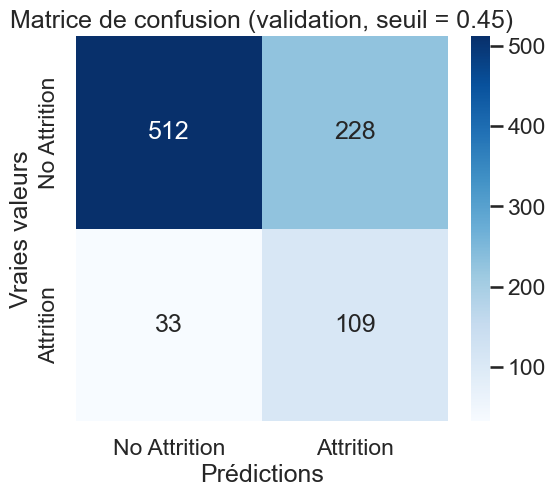

In [20]:
# -------------------------------
# Matrice de confusion (validation)
# -------------------------------
conf_matrix_val = confusion_matrix(y_val, y_pred_val_seuil)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_val,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Attrition', 'Attrition'],
    yticklabels=['No Attrition', 'Attrition']
)
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title(f"Matrice de confusion (validation, seuil = {seuil})")
plt.show()

TVP (Sensibilité) à 45% : 0.77
TFP à 45% : 0.31


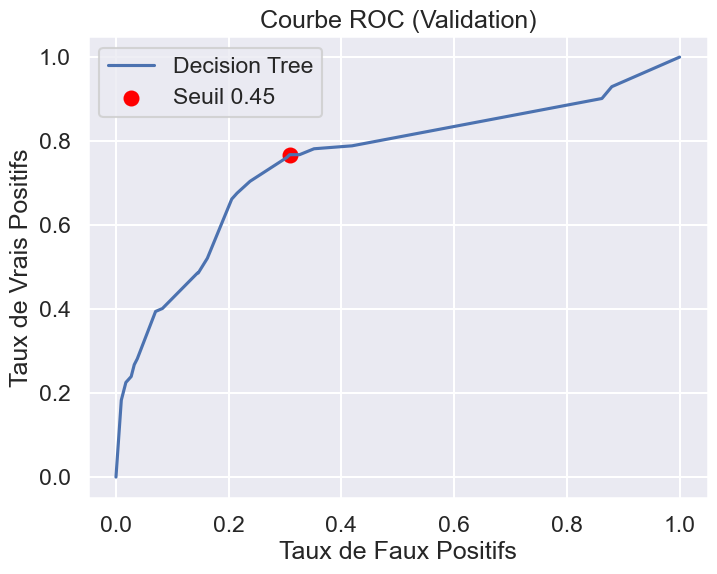

In [21]:
# -------------------------------
# TVP et TFP (validation)
# -------------------------------
tn, fp, fn, tp = conf_matrix_val.ravel()
taux_vrais_positifs = tp / (tp + fn)
taux_faux_positifs = fp / (fp + tn)

print(f"TVP (Sensibilité) à {seuil*100:.0f}% : {taux_vrais_positifs:.2f}")
print(f"TFP à {seuil*100:.0f}% : {taux_faux_positifs:.2f}")

# -------------------------------
# Courbe ROC (validation)
# -------------------------------
fpr_val, tpr_val, thresholds_val = roc_curve(y_val, y_proba_val)

plt.figure(figsize=(8, 6))
plt.plot(fpr_val, tpr_val, label="Decision Tree")

idx = np.argmin(np.abs(thresholds_val - seuil))
plt.scatter(fpr_val[idx], tpr_val[idx], color='red', s=100, label=f"Seuil {seuil}")

plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC (Validation)")
plt.legend()
plt.show()

## Etape 7 : Détection du sur-apprentisage / sous-apprentissage

In [ ]:
# -------------------------------
# Probabilités prédites sur données d'entrainement
# -------------------------------
y_proba_train = model_tree.predict_proba(X_train)[:, 1]

# -------------------------------
# Seuil personnalisé
# -------------------------------
seuil = 0.45
y_pred_train_seuil = (y_proba_train >= seuil).astype(int)

# -------------------------------
# Rapport de classification (validation et entraînement)
# -------------------------------
print("Rapport de classification des données d'entrainement (seuil = {:.2f})".format(seuil))
print(classification_report(y_train, y_pred_train_seuil))
print("ROC-AUC TRAIN :", round(roc_auc_score(y_train, y_proba_train), 3))
print("Rapport de classification des données de validation (seuil = {:.2f})".format(seuil))
print(classification_report(y_val, y_pred_val_seuil))
print("ROC-AUC :", round(roc_auc_score(y_val, y_proba_val), 3))

Rapport de classification des données d'entrainement (seuil = 0.45)
              precision    recall  f1-score   support

           0       0.96      0.71      0.81      2219
           1       0.36      0.86      0.51       427

    accuracy                           0.73      2646
   macro avg       0.66      0.78      0.66      2646
weighted avg       0.87      0.73      0.77      2646

ROC-AUC TRAIN : 0.855
Rapport de classification des données de validation (seuil = 0.45)
              precision    recall  f1-score   support

           0       0.94      0.69      0.80       740
           1       0.32      0.77      0.46       142

    accuracy                           0.70       882
   macro avg       0.63      0.73      0.63       882
weighted avg       0.84      0.70      0.74       882

ROC-AUC : 0.752


### Analyse du sur-apprentissage et du sous-apprentissage

Le modèle ne présente ni sur-apprentissage marqué, ni sous-apprentissage.  
Les performances obtenues sur les données d’entraînement et de validation sont relativement proches, ce qui indique une bonne capacité de généralisation.

On observe notamment :
- ROC-AUC entraînement : 0.855
- ROC-AUC validation : 0.752

L’écart reste modéré, ce qui montre que le modèle n’apprend pas uniquement les données d’entraînement et conserve une bonne capacité à généraliser sur de nouvelles données.

---

### Interprétation

- Pas de sur-apprentissage :  
  Les performances sur le jeu d’entraînement ne sont pas excessivement supérieures à celles de validation.

- Pas de sous-apprentissage :  
  Les scores restent corrects et suffisamment élevés, ce qui indique que le modèle capture bien les relations dans les données.

Le modèle atteint donc un bon compromis entre biais et variance.

---

### Rôle des hyperparamètres

Cette stabilité s’explique par le choix d’hyperparamètres qui permettent de contrôler la complexité du modèle :

- `max_depth=5` : limite la profondeur de l’arbre et évite un modèle trop complexe  
- `min_samples_split=10` : empêche des divisions trop spécifiques  
- `min_samples_leaf=5` : garantit des feuilles suffisamment représentatives  
- `class_weight="balanced"` : améliore la prise en compte du déséquilibre des classes  

Ces paramètres réduisent le risque de sur-apprentissage tout en évitant un modèle trop simple.

---

### Conclusion

Le modèle présente une bonne généralisation avec un écart modéré entre les performances d’entraînement et de validation.  
Il est correctement ajusté et ne montre pas de signe significatif de sur-apprentissage ni de sous-apprentissage.

## Etape 8 : Evaluation du modèle avec données de test

In [40]:
# -------------------------------
# Probabilités prédites sur test
# -------------------------------
y_proba_test = model_tree.predict_proba(X_test)[:, 1]

# -------------------------------
# Seuil personnalisé
# -------------------------------
seuil = 0.45
y_pred_test_seuil = (y_proba_test >= seuil).astype(int)

# -------------------------------
# Rapport de classification
# -------------------------------
print("Rapport de classification (test, seuil = {:.2f})".format(seuil))
print(classification_report(y_test, y_pred_test_seuil))
print("ROC-AUC :", round(roc_auc_score(y_test, y_proba_test), 3))

Rapport de classification (test, seuil = 0.45)
              precision    recall  f1-score   support

           0       0.93      0.68      0.79       740
           1       0.31      0.75      0.44       142

    accuracy                           0.69       882
   macro avg       0.62      0.71      0.61       882
weighted avg       0.83      0.69      0.73       882

ROC-AUC : 0.778


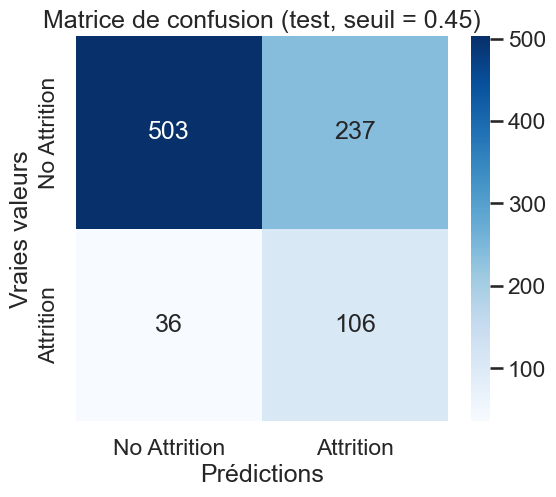

In [41]:
# -------------------------------
# Matrice de confusion (test)
# -------------------------------
conf_matrix_test = confusion_matrix(y_test, y_pred_test_seuil)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_matrix_test,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Attrition', 'Attrition'],
    yticklabels=['No Attrition', 'Attrition']
)
plt.xlabel("Prédictions")
plt.ylabel("Vraies valeurs")
plt.title(f"Matrice de confusion (test, seuil = {seuil})")
plt.show()

TVP (Sensibilité) à 45% : 0.75
TFP à 45% : 0.32


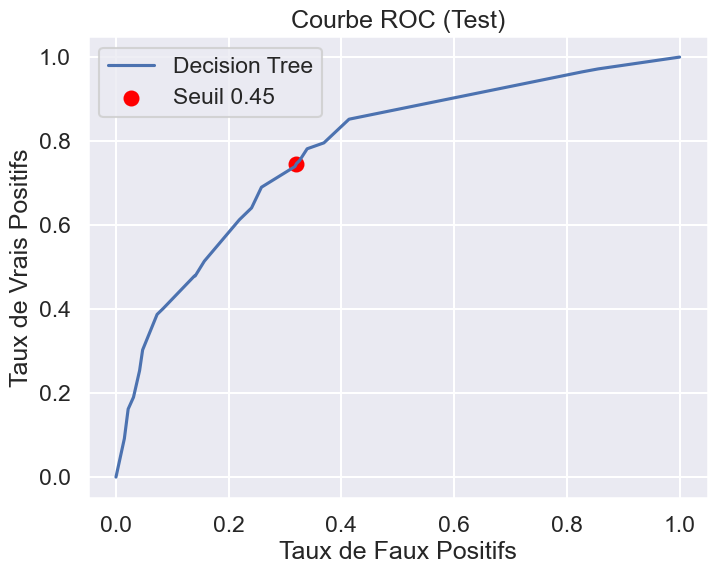

In [42]:
# -------------------------------
# TVP et TFP (test)
# -------------------------------
tn, fp, fn, tp = conf_matrix_test.ravel()
taux_vrais_positifs = tp / (tp + fn)
taux_faux_positifs = fp / (fp + tn)

print(f"TVP (Sensibilité) à {seuil*100:.0f}% : {taux_vrais_positifs:.2f}")
print(f"TFP à {seuil*100:.0f}% : {taux_faux_positifs:.2f}")

# -------------------------------
# Courbe ROC (test)
# -------------------------------
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_proba_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_test, tpr_test, label="Decision Tree")

idx = np.argmin(np.abs(thresholds_test - seuil))
plt.scatter(fpr_test[idx], tpr_test[idx], color='red', s=100, label=f"Seuil {seuil}")

plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.title("Courbe ROC (Test)")
plt.legend()
plt.show()

## Etape 9 : Prédiction pour un nouvel employé

In [43]:
nouvel_employe = pd.DataFrame([{
    "EnvironmentSatisfaction": 3,
    "JobSatisfaction": 4,
    "WorkLifeBalance": 2,
    "JobInvolvement": 3,
    "PerformanceRating": 3,
    "BusinessTravel": "Travel_Rarely",
    "Department": "Sales",
    "DistanceFromHome": 10,
    "Education": 3,
    "EducationField": "Life Sciences",
    "JobLevel": 2,
    "JobRole": "Sales Executive",
    "MonthlyIncome": 5000,
    "NumCompaniesWorked": 2,
    "PercentSalaryHike": 12,
    "StockOptionLevel": 1,
    "TotalWorkingYears": 5,
    "TrainingTimesLastYear": 3,
    "YearsAtCompany": 4,
    "YearsSinceLastPromotion": 1,
    "YearsWithCurrManager": 2,
    "2015-01_sup": 5,
    "2015-02_sup": 2,
    "2015-03_sup": 0,
    "2015-04_sup": 3,
    "2015-05_sup": 0,
    "2015-06_sup": 1,
    "2015-07_sup": 0,
    "2015-08_sup": 0,
    "2015-09_sup": 4,
    "2015-10_sup": 0,
    "2015-11_sup": 0,
    "2015-12_sup": 2
}])

In [44]:
# Calculer la probabilité pour le nouvel employé
proba = model_tree.predict_proba(nouvel_employe)[:, 1][0]

# Seuil choisi
seuil = 0.45

# Prédiction selon le seuil
prediction_seuil = 1 if proba >= seuil else 0

# Affichage
print("Prédiction avec seuil =", seuil, ":", "Yes (part)" if prediction_seuil == 1 else "No (reste)")
print("Probabilité :", round(proba, 3))

Prédiction avec seuil = 0.45 : Yes (part)
Probabilité : 0.638


## Etape 10 : Identification des facteurs ayant le plus d'influence sur le taux de rotation des employés

In [23]:
# Récupération des noms de variables après prétraitement
feature_names = model_tree.named_steps["preprocessing"].get_feature_names_out()

# Importances des variables
importances = model_tree.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Top 10 des facteurs influents les plus importants :")
print(importance_df.head(10))

Top 10 des facteurs influents les plus importants :
                                  feature  importance
14                    num__YearsAtCompany        0.20
22                       num__2015-06_sup        0.11
12                 num__TotalWorkingYears        0.10
1                    num__JobSatisfaction        0.07
0            num__EnvironmentSatisfaction        0.06
15           num__YearsSinceLastPromotion        0.06
13             num__TrainingTimesLastYear        0.06
30  cat__BusinessTravel_Travel_Frequently        0.05
5                   num__DistanceFromHome        0.05
28                       num__2015-12_sup        0.04


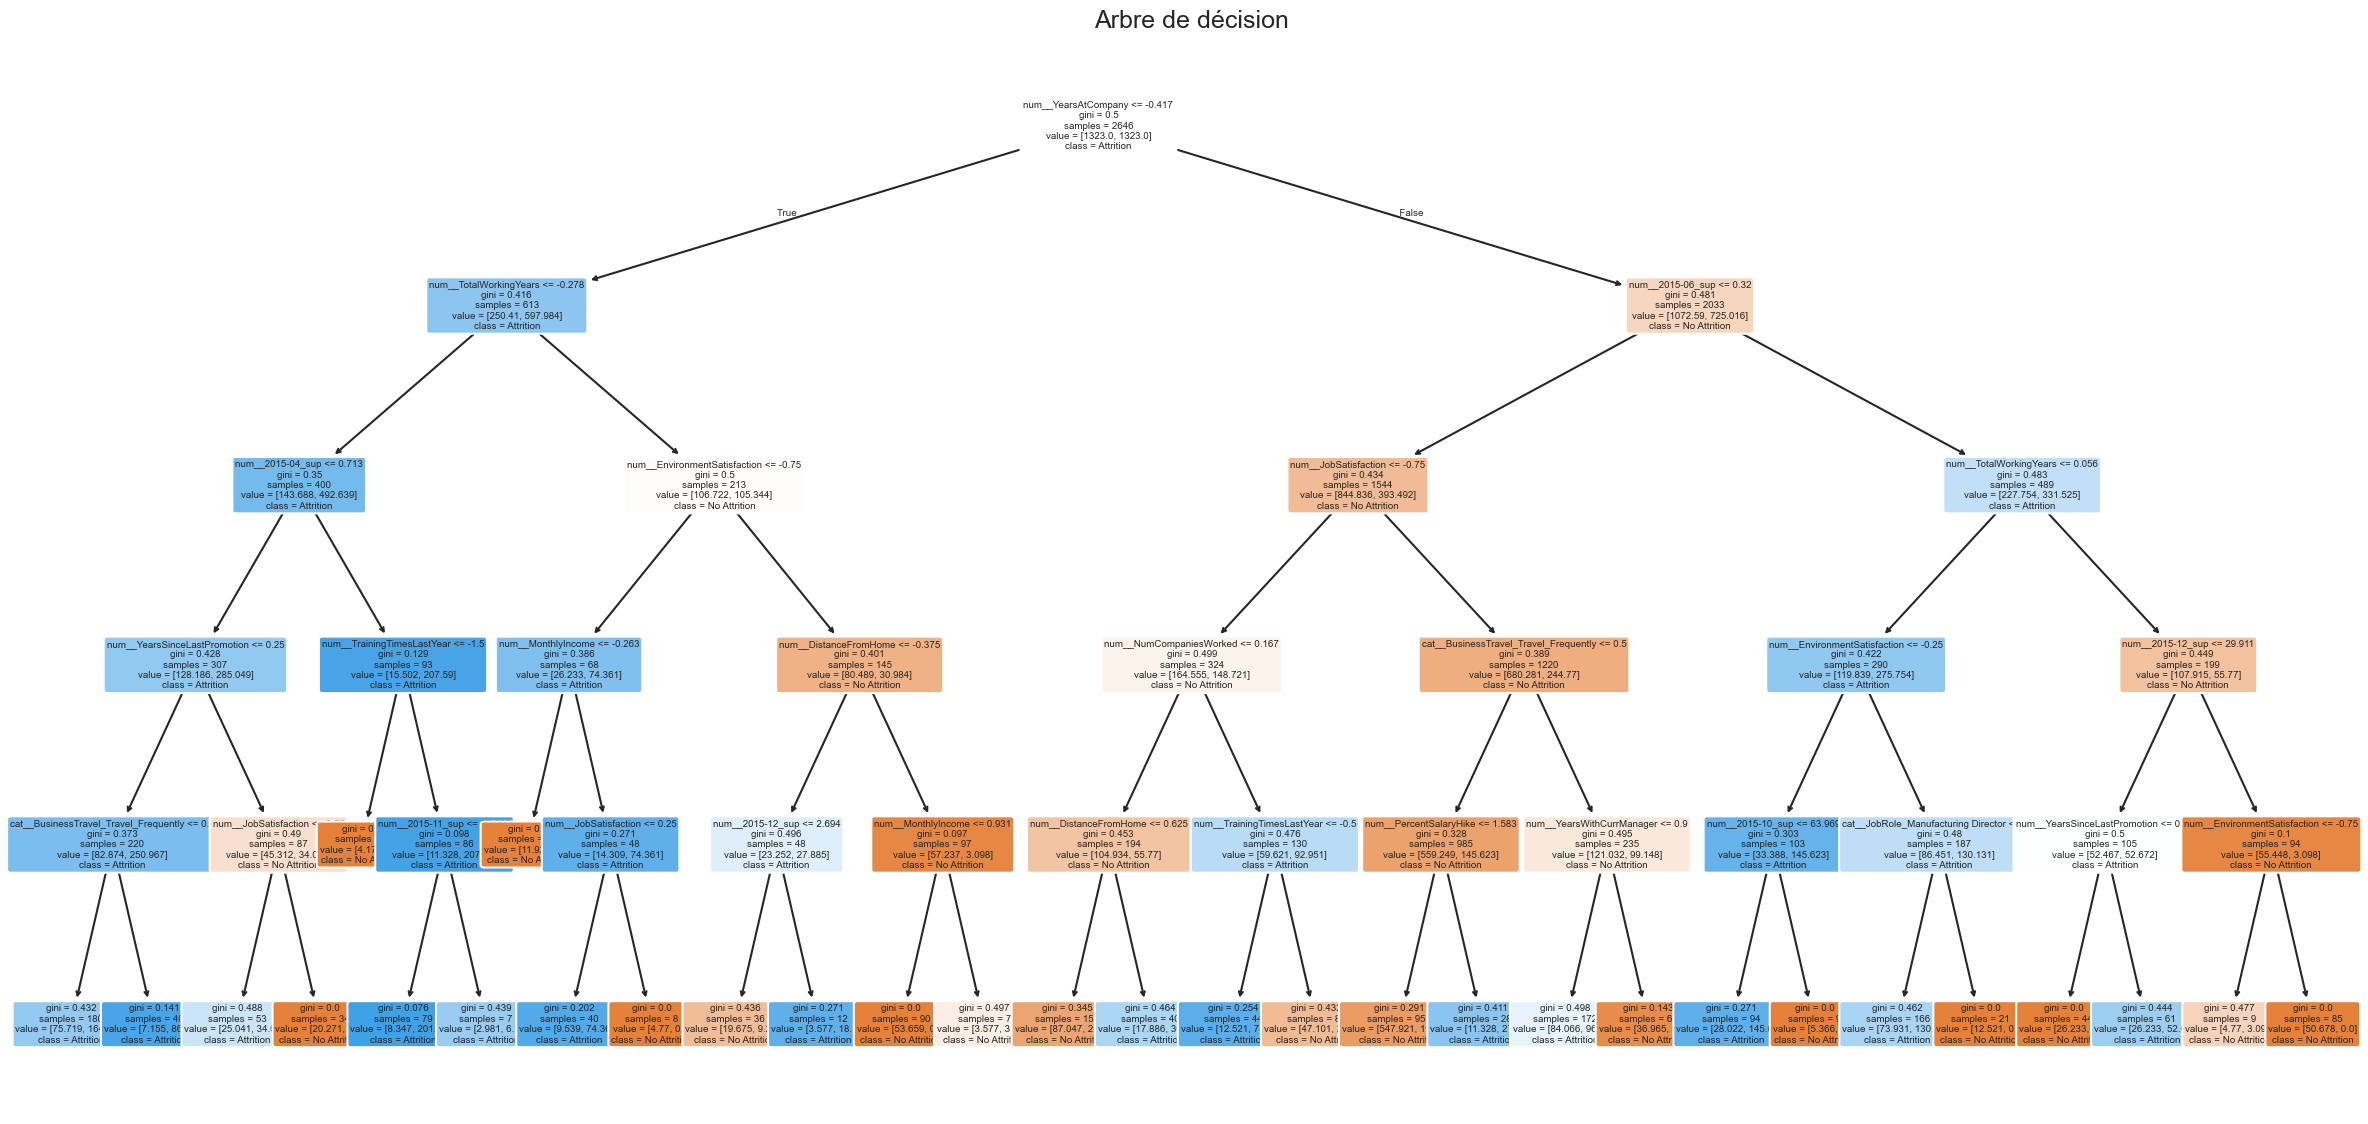

In [46]:
# Visualisation de l'arbre de décision
plt.figure(figsize=(30, 14))
plot_tree(
    model_tree.named_steps["classifier"],
    feature_names=feature_names,
    class_names=["No Attrition", "Attrition"],
    filled=True,
    rounded=True,
    fontsize=7
)
plt.title("Arbre de décision")
plt.show()

In [57]:
import joblib

joblib.dump(model_tree, "modele_arbre.pkl")

['modele_arbre.pkl']